#**Sentiment Classifier**

This is my pet-project which was done fully on my own. The goal here is to build a sentiment classifier for tweets using various NLP techniques. There are 3 sentiment categories: 'negative', 'neutral', 'positive'.

I'll try two approaches: the first one uses an LSTM-network. But this is not going to be a usual training of already implemented version of it. First of all, I'll build all the models from scratch to show understanding of their architectures. Then, pretrain token embedding for the network using Word2Vec so the model starts with meaningful context, rather than using random-initialized vectors with no encoded meaning in them. Also, as we usualy already have the full text of a tweet, using bidirectional modification of the network seems a reasonable decision.

The second approach uses more modern techniques than old-fashioned LSTM, but this is going to more rely on using pretrained things and ready implementations, just to compare the results with the pipeline above and to show familiarity with LLMs

Despite the first option uses older alternatives, it really shows the essense of the machine learning process: prepraring datasets, tuning different hyperparameters, modifying architectures and applying different NLP intuitions

In [3]:
import numpy as np
import json
import matplotlib.pyplot as plt
import umap
from typing import Iterable, List, Dict, Optional, Union, Tuple, Self, Any

seed = 42
np.random.seed(seed)
%matplotlib inline

In [2]:
import torch
import torch.nn as nn
import torch.autograd  as autograd
import torch.optim as optim
import torch.nn.functional as F
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

In [ ]:
# if using Colab, run this cell and restart the session afterwards
!pip install -U datasets
!pip install contractions

### **1. Representation learning**

In this part, we're going to train token embeddings using plain Word2Vec. The implementation mostly follows well-known Mikolow's articles:


*   [Efficient estimation of word representations in vector space](https://arxiv.org/pdf/1301.3781)
*   [Distributed representations of words and phrases and their compositionality](https://proceedings.neurips.cc/paper/2013/file/9aa42b31882ec039965f3c4923ce901b-Paper.pdf)



Define utility classes, they will help with the training process:

In [4]:
from nltk.tokenize import RegexpTokenizer
from collections import Counter
from itertools import chain

class Vocabulary:
    """A class for building and managing a vocabulary of dataset tokens.

    This class maintains mappings between tokens and their IDs and appending
    existing vocabulary with new datasets

    Attributes:
        token_to_id: Mapping from token strings to their corresponding integer IDs.
        id_to_token: List of tokens indexed by their integer ID. Inverse of `token_to_id`.
        tokens_counter: collections.Counter, contains
        size: Number of unique tokens in the vocabulary.
        special_tokens: Tokens such as `<PAD>` or `<UNK>`
            that are always included at the beginning of the vocabulary.
    """
    def __init__(self, texts: Iterable[Iterable[str]], special_tokens: List[str] = ['[PAD]', '[UNK]']):
        """Initialize Vocabulary with given text.

        Args:
            texts: A collection of tokenized sentences,
                e.g., [["hello", "world"], ["the", "church", "is", "closed", "dude"]].
        """
        self.special_tokens = special_tokens
        self.tokens_counter = Counter({token: 0 for token in special_tokens})
        self.tokens = set(special_tokens)
        self.id_to_token = special_tokens
        self.token_to_id = {token: idx for idx, token in enumerate(self.id_to_token)}

        self.add_text(texts)

    def add_text(self, texts: Iterable[Iterable[str]]) -> None:
        """Add tokens from the given text to the vocabulary.

        Args:
            texts: A collection of tokenized sentences.
        """
        text_tokens_counter = Counter(chain.from_iterable(texts))
        for token, token_count in text_tokens_counter.items():
            self.__add_token(token, token_count)

    def size(self) -> int:
        """Get the number of unique tokens in the vocabulary.

        Returns:
            Vocabulary size.
        """
        return len(self.tokens)

    def to_dict(self) -> Dict[str, Any]:
        """Convert the vocabulary into a serializable dictionary.

        Returns:
            Dictionary containing counters and mappings.
        """
        return {
            "tokens_counter": dict(self.tokens_counter),
            "id_to_token": self.id_to_token,
            "token_to_id": self.token_to_id
        }

    @classmethod
    def from_dict(cls, data: Dict[str, Any]) -> Self:
        """Recreate a Vocabulary instance from a dictionary.

        Args:
            data: Dictionary with vocabulary data.

        Returns:
            A restored Vocabulary instance.
        """
        obj = cls.__new__(cls)  # bypass __init__
        obj.tokens_counter = Counter(data["tokens_counter"])
        obj.tokens = set(data["id_to_token"])
        obj.id_to_token = data["id_to_token"]
        obj.token_to_id = data["token_to_id"]
        return obj

    def __add_token(self, token, token_count):
        if token in self.tokens:
            self.tokens_counter[token] += token_count
        else:
            self.tokens_counter[token] = token_count
            self.tokens.add(token)
            self.id_to_token.append(token)
            self.token_to_id[token] = len(self.id_to_token) - 1

In [5]:
import contractions

class TextBatchGenerator():
    """Batch generator for text data with optional labels.

    This generates random batches from the text dataset for training
    purposes. Index sampling is reproducible using a fixed random seed.
    """
    def __init__(self,
                 texts: Iterable[Iterable[int]],
                 text_labels: Optional[Iterable[int]] = None,
                 random_state: int = 1):
        """
        Initialize the batch generator.

        Args:
            texts: Tokenized texts, where each text is
                   represented as a sequence of tokens IDs.
            text_labels: Labels corresponding to each text. Returned alongside the text if provided.
            random_state: Seed for the random number generator to ensure reproducibility.
        """
        self.texts = texts
        self.text_labels = text_labels
        self.__random_generator = np.random.default_rng(seed=random_state)
        self.__index_generator = self.__index_generator()

    def generate_batch(self, batch_size) -> Union[List[List[int]], Tuple[List[List[int]], List]]:
        """Generate a random batch of texts (and optionally corresponding labels).

        Args:
            batch_size: Number of texts (and labels) in the batch.

        Returns:
                If `text_labels` is provided, returns a tuple `(texts, labels)`.
                Otherwise, returns only the list of texts.
        """
        indexes = [next(self.__index_generator) for i in range(batch_size)]
        texts = [self.texts[index] for index in indexes]
        if self.text_labels is not None:
            text_labels = [self.text_labels[index] for index in indexes]
            return texts, text_labels
        else:
            return texts

    def __index_generator(self):
        """Infinite generator that yields shuffled indexes of texts"""
        num_texts = len(self.texts)
        while True:
            indexes = self.__random_generator.integers(num_texts, size=num_texts)
            for index in indexes:
                yield index

In [6]:
class TextPreprocessor:
    """
    Utility class for text preprocessing.

    This class provides methods to transform raw text into the form
    suitable for training models. Includes token replacement, contraction fixing
    tokenization and converting to numbers.
    """
    @staticmethod
    def replace_tokens(text: str, token_replacements: Dict[str, str]) -> str:
        """Replace tokens in a string with provided replacements.

        Args:
            text: Input text.
            token_replacements: Mapping of tokens to replace,
                where keys are tokens to be replaced and values are replacement tokens.

        Returns:
            The text with tokens replaced.
        """

        for token, replacement_token in token_replacements.items():
            text = text.replace(token, replacement_token)
        return text

    @staticmethod
    def fix_contractions(text: str) -> str:
        """Expand contractions in the given text (e.g., "don't" → "do not").

        Args:
            text: Input text.

        Returns:
            Text with contractions expanded.
        """
        return contractions.fix(text)

    @staticmethod
    def tokenize(text: str, tokenizer) -> List[str]:
        """Tokenize the input text using a provided tokenizer.

        Args:
            text: Input text.
            tokenizer: Tokenizer object with a `.tokenize()` method.

        Returns:
            List of tokens.
        """
        return tokenizer.tokenize(text)

    @staticmethod
    def encode_text(texts: Iterable[Iterable[str]], vocabulary: Vocabulary, unknown_token: str  = '[UNK]') -> List[List[int]]:
        """Convert each token from the text to its corresponding ID from the vocabulary.

        Args:
            texts: A collection of tokenized sentences
            vocabulary: A Vocabulary object.
            unknown_token: A replacement token for tokens not found in vocabulary
        Returns:
            List of tokens IDs.
        """
        encoded_texts = []
        for text in texts:
            encoded_text = []
            for token in text:
                if token in vocabulary.tokens:
                    token_id = vocabulary.token_to_id[token]
                else:
                    token_id = vocabulary.token_to_id[unknown_token]
                encoded_text.append(token_id)
            encoded_texts.append(encoded_text)
        return encoded_texts

    @classmethod
    def preprocess(cls,
                   texts: Iterable[str],
                   tokenizer,
                   token_replacements: Optional[Dict[str, str]] = None,
                   make_lowercase: bool = True) -> List:
        """Apply preprocessing pipeline to a list of texts.

        Steps include:
          - lowercasing (optional),
          - replacing tokens,
          - fixing contractions,
          - tokenizing with the provided tokenizer.
          - converting tokens to their IDs from the given Vocabulary

        Args:
            texts: Collection of raw text strings.
            tokenizer: Tokenizer object with a `.tokenize()` method.
            token_replacements: Mapping of tokens to replacements.
            make_lowercase: Whether to lowercase the text.

        Returns:
            List of tokenized and preprocessed texts.
        """
        preprocessed_text = []
        for text in texts:
            if make_lowercase:
                text = text.lower()
            if token_replacements is not None:
                text = cls.replace_tokens(text, token_replacements)
            text = cls.fix_contractions(text)
            preprocessed_text.append(cls.tokenize(text, tokenizer))
        return preprocessed_text

Classes for context pair generation:

In [7]:
from utils import calculate_token_frequencies

class ContextPairGenerator:
    """Generates (center, context) word pairs for training Word2Vec (skip-gram) models.

    The generation of context pairs is implemented in a fast, vectorized manner
    to efficiently handle large batches of texts.
    Implements subsampling of frequent words according to Mikolov et al. (2013).

    Attributes:
        window_size: maximum distance between center and context words.
        buffer_size: number of raw pairs to generate per internal buffer. Balance between speed/memory consumption.
    """
    def __init__(self, texts:
                 Iterable[Iterable[str]],
                 vocabulary: Vocabulary,
                 window_size: int,
                 buffer_size: int = 100_000,
                 random_state: int = None):
        """Initialize ContextPairGenerator.

        Args:
            texts:  A collection of tokenized sentences.
            vocabulary: A Vocabulary object.
            window_size: maximum distance between center and context words.
            buffer_size: number of raw pairs to pre-generate per internal buffer.
            random_state: seed for reproducible randomness.
        """
        self.window_size = window_size
        self.buffer_size = buffer_size
        self.__token_frequencies = calculate_token_frequencies(vocabulary)
        self.__pairs_generator = self.__generate_context_pairs()
        self.__random_generator = np.random.default_rng(seed=random_state)
        self.__text_generator = TextBatchGenerator(texts, vocabulary, random_state)

    def get_batch(self, batch_size: int) -> torch.Tensor:
        """Returns a batch of (center, context) pairs.

        Args:
            batch_size: number of pairs to return.

        Returns:
            torch.Tensor of shape (batch_size, 2).
        """
        batch = []
        for i in range(batch_size):
            context_pair = next(self.__pairs_generator)
            batch.append(context_pair)
        return torch.tensor(np.array(batch))

    def __generate_context_pairs(self):
        """Infinite generator yielding subsampled (center, context) pairs."""
        while True:
            context_pairs = self.__sample_raw_pairs(size=self.buffer_size)
            context_pair_keep_mask = self.__get_context_pair_keep_mask(context_pairs)
            context_pairs = context_pairs[context_pair_keep_mask]

            for context_pair in context_pairs:
                yield context_pair

    def __sample_raw_pairs(self, size):
        """Pregenerate raw (center, context) pairs in vectorized manner, before subsampling."""
        texts = self.__text_generator.generate_batch(batch_size=size)
        text_lengths = np.array([len(text) for text in texts])

        center_indexes = self.__random_generator.integers(text_lengths)

        possible_offsets = np.arange(-self.window_size, self.window_size + 1)
        possible_offsets = possible_offsets[possible_offsets != 0]
        offsets = self.__random_generator.choice(possible_offsets, size=size)
        context_indexes = np.clip(center_indexes + offsets, 0, text_lengths - 1)

        context_pairs = []
        for center_index, context_index, text in zip(center_indexes, context_indexes, texts):
            center = text[center_index]
            context = text[context_index]
            context_pairs.append((center, context))
        return np.array(context_pairs)

    def __get_context_pair_keep_mask(self, context_pairs):
        """Generate boolean mask of subsampling context pairs.

        Formula used:
        p_keep = 1 - p_discard, p_discard = 1 - t / p_token, where

        p_keep – probability of keeping the token, p_discard – probaility of discrading the token,
        p_token – frequency of the token, t – threshold constant.
        """
        threshold_constant = 1e-5

        token_frequencies = self.__token_frequencies[context_pairs]
        token_keep_probabilities = np.sqrt(threshold_constant / token_frequencies)
        token_keep_probabilities[token_keep_probabilities > 1] = 1

        token_keep_mask = self.__random_generator.random(size=context_pairs.shape) < token_keep_probabilities
        pair_keep_mask = token_keep_mask.all(axis=1)
        return pair_keep_mask

class NegativeSampleGenerator:
    """Generates negative samples for skip-gram Word2Vec.

    Attributes:
        vocab_size: vocabulary size.
        neg_count: number of negative samples per positive pair.
    """
    def __init__(self, vocabulary: Vocabulary, neg_count: int, random_state: int = 1):
        """Initializes NegativeSampleGenerator.

        Args:
            vocabulary: a Vocabulary object.
            neg_count: number of negative samples per positive pair.
            random_state: seed for reproducibility.
        """
        self.vocab_size = vocabulary.size()
        self.neg_count = neg_count
        self.__words_distribution = self.__calculate_words_distribution(vocabulary)
        self.__random_generator = np.random.default_rng(seed=random_state)

    def get_batch(self, batch_size: int) -> np.ndarray:
        """Returns a batch of negative samples.

        Args:
            batch_size: number of positive pairs to sample negatives for.

        Returns:
            torch.Tensor of shape (batch_size, neg_count).
        """
        negative_sample_batch = self.__random_generator.choice(self.vocab_size, size=(batch_size, self.neg_count), p=self.__words_distribution)
        return torch.tensor(negative_sample_batch)

    def __calculate_words_distribution(self, vocabulary):
        distortion_exponent = 0.75

        word_frequencies = calculate_token_frequencies(vocabulary)
        word_distribution = word_frequencies ** distortion_exponent
        word_distribution = word_distribution / word_distribution.sum()

        return word_distribution

class Word2VecBatchGenerator():
    """Generator of context_pairs and negative sample batches.

    Combines ContextPairGenerator and NegativeSampleGenerator to yield positive and negative batches suitable for skip-gram training.
    """
    def __init__(self, text, vocabulary, window_size=10, neg_count=5, random_state=1):
        """Initalize Word2VecBatchGenerator.

        Args:
            texts: A collection of tokenized sentences.
            vocabulary: A Vocabulary object.
            window_size: maximum distance between center and context.
            neg_count: number of negative samples per positive pair.
            random_state: seed for reproducibility.
        """
        self.__context_pair_generator = ContextPairGenerator(text, vocabulary, window_size, random_state)
        self.__negative_sample_generator = NegativeSampleGenerator(vocabulary, neg_count, random_state)

    def get_context_pair_batch(self, batch_size: int) -> torch.Tensor:
        """Returns a batch of positive (center, context) pairs as a torch tensor.

        Args:
            batch_size: number of pairs.

        Returns:
            torch.Tensor of shape (batch_size, 2)
        """
        context_pairs_batch = self.__context_pair_generator.get_batch(batch_size)
        return context_pairs_batch

    def get_negative_sample_batch(self, batch_size: int) -> torch.Tensor:
        """Returns a batch of negative samples as a torch tensor.

        Args:
            batch_size: number of positive pairs to generate negatives for.

        Returns:
            torch.Tensor of shape (batch_size, neg_count).
        """
        negative_batch = self.__negative_sample_generator.get_batch(batch_size)
        return negative_batch

In [8]:
class Word2VecModel(nn.Module):
    """Skip-gram Word2Vec model implemented with PyTorch.

    The model learns two embedding matrices: one for words and one for
    contexts. Training encourages words to have similar embeddings to
    their surrounding context words.

    Args:
        embedding_size: Dimensionality of the embedding vectors.
        vocab_size: Number of unique tokens in the vocabulary.

    Attributes:
        word_embedding: Embedding layer mapping token IDs
            to word embeddings.
        context_embedding: Embedding layer mapping token IDs
            to context embeddings.
    """
    def __init__(self, embedding_size: int, vocab_size: int):
        super(Word2VecModel, self).__init__()
        self.word_embedding = nn.Embedding(vocab_size, embedding_size)
        self.context_embedding = nn.Embedding(vocab_size, embedding_size)

    def forward(self, word: torch.Tensor, context: torch.Tensor) -> torch.Tensor:
        word_embedding = self.word_embedding(word)
        context_embedding = self.context_embedding(context)
        logits = torch.sum(word_embedding * context_embedding, dim=1)
        return logits

For the embeddings training, we will choose the [BBC-news dataset](https://huggingface.co/datasets/permutans/fineweb-bbc-news), because it's big, neutral, quite general and has a lot of different contexts.

In [ ]:
from datasets import load_dataset

raw_news_dataset = load_dataset("permutans/fineweb-bbc-news", "sample-100BT")

regexp = r"[A-Za-z]+"
tokenizer = RegexpTokenizer(regexp)
token_replacements = {r"\n": " ", r"\'": "'"}

news_dataset = TextPreprocessor.preprocess(raw_news_dataset['train']['text'], tokenizer, token_replacements)

In [13]:
vocabulary = Vocabulary(news_dataset)
news_dataset = TextPreprocessor.encode_text(news_dataset, vocabulary)

In [9]:
CUDA_DEVICE_IDX = 0
device = torch.device(f"cuda:{CUDA_DEVICE_IDX}") if torch.cuda.is_available() else torch.device("cpu")

In [14]:
batch_size = 1024
num_iterations = 100_000
embedding_size = 128
learning_rate = 1e-2

loss_history = []

batchifier = Word2VecBatchGenerator(news_dataset, vocabulary, window_size=10, neg_count=10, random_state=seed)
word2vec_model = Word2VecModel(embedding_size=embedding_size, vocab_size=vocabulary.size()).to(device)
optimizer = torch.optim.Adam(word2vec_model.parameters(), lr=learning_rate)

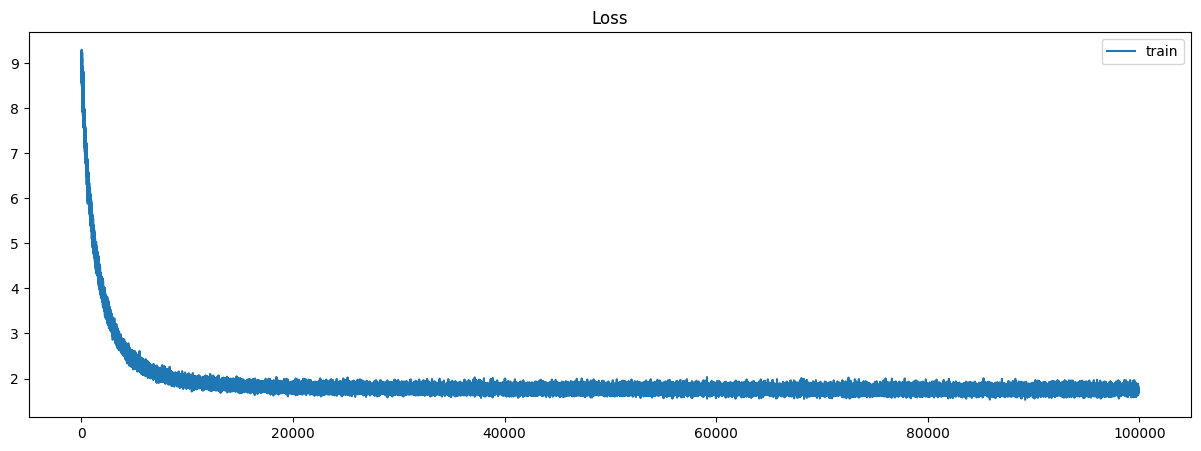

In [15]:
from IPython.display import clear_output
from utils import compute_positive_logits, compute_negative_logits, calculate_loss, plot_train_process

for step in range(num_iterations):
    context_batch = batchifier.get_context_pair_batch(batch_size=batch_size)
    centers = context_batch[:, 0].to(device)
    contexts = context_batch[:, 1].to(device)
    negative_sample = batchifier.get_negative_sample_batch(batch_size=batch_size).to(device)

    positive_logits = compute_positive_logits(word2vec_model, centers, contexts)
    negative_logits = compute_negative_logits(word2vec_model, centers, negative_sample)

    loss = calculate_loss(positive_logits, negative_logits)

    loss.backward()

    optimizer.step()

    optimizer.zero_grad()
    loss_history.append(loss.item())

    if step % 100 == 0:
        clear_output(True)
        plot_train_process(loss_history)

As the dataset is very big (~100K texts and average text size is ~50-60 tokens), it takes enormous amount of time to complete one epoch, thus we limit the process with the particular number of iterations. Experimentally, starting from 30k iterations the model begins to show the reasonable results and with 100k being a reasonable tradeoff between learning time and the embeddings quality.

Despite the learning curve went to the plateau at the 30k iterations point, training beyond that keeps showing better results. That's because the loss shows how well the Word2Vec model can predict the contexts by the central word, which sligtly differs from the actual quality of the embeddings, for example very frequent words have a lot of possible contexts, but improving the quality of more specific words doesn't put too much into the results

In [16]:
def get_closest_contexts(word, num_closest=10):
    """Find the closest words to the given word in embedding space using cosine similarity.

    Args:
        word: Target word.
        num_closest: Number of closest words to return.

    Returns:
        List[str]: Closest words from the vocabulary.
    """
    word_id = torch.tensor(vocabulary.token_to_id[word]).to(device)
    word_embedding = word2vec_model.word_embedding(word_id)

    contexts_embeddings = word2vec_model.context_embedding.weight
    similarity_matrix = F.cosine_similarity(word_embedding, contexts_embeddings)
    closest_words = torch.argsort(similarity_matrix)[-num_closest:].cpu().numpy()
    return [vocabulary.id_to_token[id] for id in closest_words]

You can play with this by yourself, just load the word2vec model and write your own word to find the closest contexts to it

In [ ]:
with open("vocabulary.json", "r", encoding="utf-8") as vocab_file:
    data = json.load(vocab_file)
vocabulary = Vocabulary.from_dict(data)

word2vec_model = Word2VecModel(embedding_size=embedding_size, vocab_size=vocabulary.size()).to(device)
word2vec_model.load_state_dict(torch.load('.models/embeddings.pth', map_location=device))

<All keys matched successfully>

In [ ]:
word = 'Ukraine'
get_closest_contexts(word.lower(), num_closest=30)

['syrian',
 'monica',
 'sentiment',
 'belgium',
 'bulgaria',
 'marwahin',
 'crimea',
 'sergei',
 'glow',
 'cordoned',
 'poland',
 'floated',
 'europol',
 'mikhail',
 'protested',
 'steps',
 'ski',
 'pieniny',
 'friday',
 'caruana',
 'turkey',
 'czech',
 'ukraine',
 'talks',
 'kaczynski',
 'fukushima',
 'strikes',
 'khmelnytskyy',
 'lifenews',
 'kiev']

Let's draw the visualisation of embeddings using UMAP:

In [ ]:
embeddings = word2vec_model.word_embedding.weight.data.cpu().numpy()
umap_embeddings = umap.UMAP(n_neighbors=5).fit_transform(embeddings)

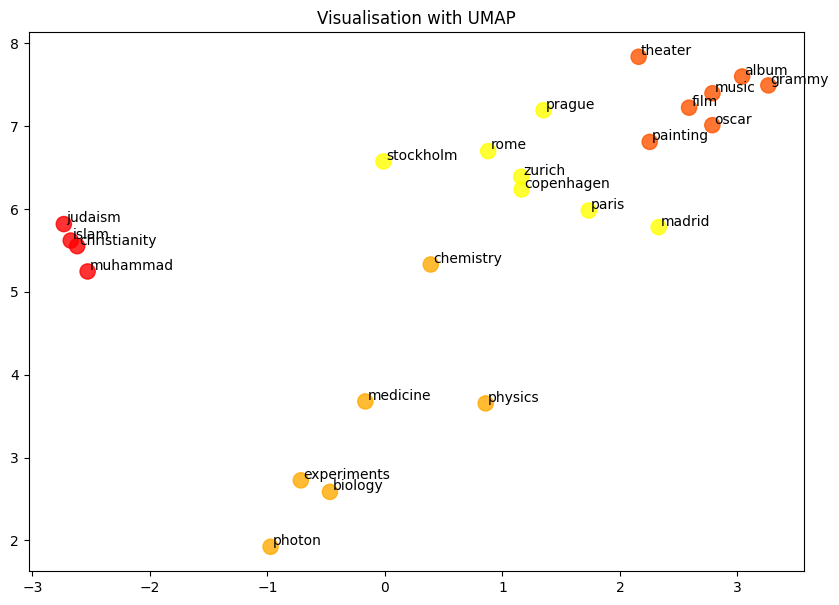

In [ ]:
categories = {
    "religions": ["islam", "christianity", "judaism", 'muhammad'],
    "culture": ["film", "theater", "painting", "oscar", "music", 'grammy', 'album'],
    "professions": ["medicine", "physics", "chemistry", "biology", "experiments", 'photon'],
    'cities': ['paris', 'madrid', 'rome', 'copenhagen', 'zurich', 'prague', 'stockholm']
}

words = [word for category in categories.values() for word in category]
words_ids = np.array([vocabulary.token_to_id[word] for word in words])
points = umap_embeddings[words_ids]

color_map = {label: i for i, label in enumerate(categories.keys())}
colors = [color_map[category] for category in categories for i in range(len(categories[category]))]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    points[:, 0], points[:, 1],
    c=colors, cmap="autumn", alpha=0.8, s=120
)

for i, word in enumerate(words):
    plt.text(points[i, 0] + 0.02, points[i, 1] + 0.02, words[i], fontsize=10)

plt.title("Visualisation with UMAP")
plt.show()

###**2. Classifier training**




Here we implement and train a biderictional LSTM network that output the sentiment class for a given tweet

In [3]:
class LSTMCell(nn.Module):
    """A single LSTM cell implementation with explicit gates:
    input, forget, cell, and output gates.

    Args:
        input_size: Dimensionality of the input features.
        hidden_size: Dimensionality of the hidden and cell state.
    """
    def __init__(self, input_size: int, hidden_size: int):
        super(LSTMCell, self).__init__()
        self.hidden_size = hidden_size
        self.input_size = input_size

        concatenated_size = hidden_size + input_size
        self.input_gate = nn.Linear(concatenated_size, hidden_size)
        self.forget_gate = nn.Linear(concatenated_size, hidden_size)
        self.cell_gate = nn.Linear(concatenated_size, hidden_size)
        self.output_gate = nn.Linear(concatenated_size, hidden_size)

    def forward(self, token: torch.Tensor, hidden_state: torch.Tensor, cell_state: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        token_and_hidden = torch.cat([token, hidden_state], dim=-1)

        forget_activation = torch.sigmoid(self.forget_gate(token_and_hidden))
        cell_candidate = torch.tanh(self.cell_gate(token_and_hidden))
        input_activation = torch.sigmoid(self.input_gate(token_and_hidden))
        new_cell_state = forget_activation * cell_state + input_activation * cell_candidate

        output_activation = torch.sigmoid(self.output_gate(token_and_hidden))
        new_hidden_state = output_activation * torch.tanh(new_cell_state)

        return new_hidden_state, new_cell_state

class LSTM(nn.Module):
    """A simple unidirectional LSTM implemented from scratch using LSTMCell.
    Processes sequences token by token to produce the final hidden state.

    Args:
        input_size: Dimensionality of the input features per token.
        hidden_size: Dimensionality of the hidden and cell states.
        batch_first: If True, input is shaped (batch, seq_len, input_size), (seq, batch, feature) – otherwise.
    """
    def __init__(self, input_size: int, hidden_size: int, batch_first: bool = True):
        super(LSTM, self).__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.cell = LSTMCell(self.input_size, self.hidden_size)
        self.batch_first = batch_first

    def forward(self, input_sequence: torch.Tensor) -> torch.Tensor :
        if self.batch_first:
            input_sequence = input_sequence.transpose(0, 1)
        batch_size = input_sequence.shape[1]
        hidden_state = input_sequence.new_zeros(batch_size, self.hidden_size)
        cell_state = input_sequence.new_zeros(batch_size, self.hidden_size)
        for token in input_sequence:
            hidden_state, cell_state = self.cell(token, hidden_state, cell_state)
        return hidden_state

In [4]:
class BidirectionalLSTM(nn.Module):
    """A custom implementation of a bidirectional LSTM using two unidirectional LSTMs:
    one processing the sequence in the forward direction and one in reverse.
    The outputs from both directions are concatenated to form the final hidden state.
i
    Args:
        input_size: Dimensionality of the input features per token.
        hidden_size: Number of hidden units in each LSTM direction.
        batch_first: If True, input/output tensors are shaped (batch, seq, feature), (seq, batch, feature) – otherwise.
    """
    def __init__(self, input_size: int, hidden_size: int, batch_first: bool =True):
        super(BidirectionalLSTM, self).__init__()
        self.forward_network = LSTM(input_size, hidden_size, batch_first)
        self.backward_network = LSTM(input_size, hidden_size, batch_first)
        self.batch_first = batch_first

    def forward(self, input_sequence: torch.Tensor) -> torch.Tensor:
        direct_sequence = input_sequence
        if self.batch_first:
            sequence_dim = 1
        else:
            sequence_dim = 0
        reverse_sequence = torch.flip(input_sequence, dims=[sequence_dim])

        forward_hidden_state = self.forward_network(direct_sequence)
        backward_hidden_state = self.backward_network(reverse_sequence)
        joint_hidden_state = torch.cat((forward_hidden_state, backward_hidden_state), dim=-1)
        return joint_hidden_state

Fot sentiment classification we're going to use another [dataset](https://huggingface.co/datasets/mteb/tweet_sentiment_extraction), special for this task

In [ ]:
twitter_dataset = load_dataset("mteb/tweet_sentiment_extraction")

twitter_train_and_validation = twitter_dataset['train']
train_validation_split = twitter_train_and_validation.train_test_split(test_size=0.1, seed=seed)
twitter_train = train_validation_split['train']
twitter_validation = train_validation_split['test']

regexp = r"[a-zA-Z]+|[!?]"
tokenizer = RegexpTokenizer(regexp)
tokens_replacements = {"`": "'"}

twitter_train_texts = TextPreprocessor.preprocess(twitter_train['text'], tokenizer, tokens_replacements)
twitter_validation_texts = TextPreprocessor.preprocess(twitter_validation['text'], tokenizer, tokens_replacements)

train_labels = np.array(twitter_train['label'])
validation_labels = np.array(twitter_validation['label'])

vocabulary.add_text(twitter_train_texts)

The classes are distributed pretty evenly with 'neutral' beight slightly more popular

In [ ]:
np.unique(train_labels, return_counts=True)[1] / train_labels.size

array([0.28684722, 0.40019452, 0.31295825])

In [19]:
from collections import OrderedDict

hidden_size = 64
num_classes = np.unique(train_labels).size
vocabulary_size = vocabulary.size()

lstm_classifier = nn.Sequential(OrderedDict(
    [
        ("embedding", nn.Embedding(vocabulary_size, embedding_size)),
        ("BiLSTM", BidirectionalLSTM(embedding_size, hidden_size)),
        ("output", nn.Linear(2 * hidden_size, num_classes))
    ]
))

lstm_classifier = lstm_classifier.to(device)

In [ ]:
word2vec_embeddings = word2vec_model.word_embedding.weight
with torch.no_grad():
    network_embeddings = lstm_classifier[0].weight
    word2vec_embeddings = word2vec_embeddings.to(dtype=network_embeddings.dtype, device=device)

    network_embeddings[ : word2vec_embeddings.shape[0], :].copy_(word2vec_embeddings)
    network_embeddings[word2vec_embeddings.shape[0] : , :].zero_()

In [ ]:
batch_size = 256
maximum_learning_rate = 1e-2
minimum_learning_rate = 1e-5
num_epochs = 3

iterations_per_epoch = len(twitter_train_texts) / batch_size
num_iterations = int(iterations_per_epoch * num_epochs)

warmup_proportion = 0.1
num_warmup_steps = int(warmup_proportion * num_iterations)
num_decay_steps = num_iterations - num_warmup_steps

We've added a learning rate scheduler here to lower learning rate as the process goes, with warmup to reduce instability at the beggining

In [ ]:
from utils import texts_to_matrix

twitter_train_texts = TextPreprocessor.encode_text(twitter_train_texts, vocabulary)
text_batch_generator = TextBatchGenerator(twitter_train_texts, text_labels=train_labels, random_state=seed)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lstm_classifier.parameters(), lr=maximum_learning_rate)
warmup_scheduler = LinearLR(optimizer, total_iters=num_warmup_steps)
cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_decay_steps, eta_min=minimum_learning_rate)
scheduler = SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[num_warmup_steps])

train_loss_history = []
validation_loss_history = []

To monitor the training process we're also going to calculate the validation loss. As the validation part isn't big ~2k tweets, we will calculate the loss on the whole validation

In [ ]:
twitter_validation_texts = TextPreprocessor.encode_text(twitter_validation_texts, vocabulary)
validation_matrix = texts_to_matrix(twitter_validation_texts).to(device)
validation_labels = torch.tensor(validation_labels).to(device)

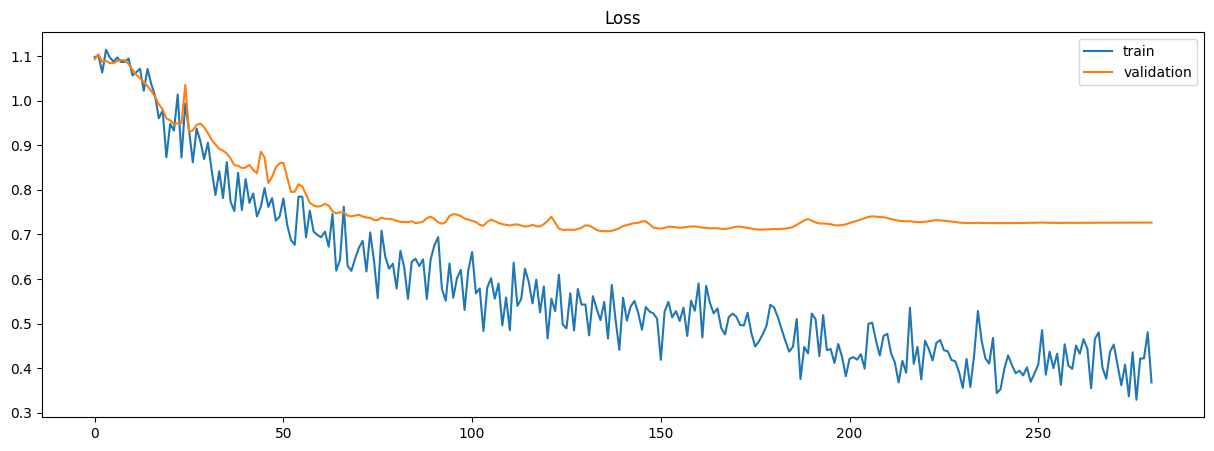

In [ ]:
for step in range(num_iterations):
    batch_texts, batch_labels = text_batch_generator.generate_batch(batch_size=batch_size)
    text_matrix = texts_to_matrix(batch_texts).to(device)
    batch_labels = torch.tensor(batch_labels).to(device)

    optimizer.zero_grad()

    train_logits = lstm_classifier(text_matrix)

    train_loss = loss_function(train_logits, batch_labels)

    with torch.no_grad():
        validation_logits = lstm_classifier(validation_matrix)
        validation_loss = loss_function(validation_logits, validation_labels)
        validation_loss_history.append(validation_loss.item())

    train_loss.backward()

    optimizer.step()

    scheduler.step()

    train_loss_history.append(train_loss.item())

    if step % 10 == 0:
        clear_output(True)
        plot_train_process(train_loss_history, validation_loss_history)

As we can see, the validation loss curve went to plateau around 2-nd epoch (~150 iterations).

After tuning all the hyperparameters we retrain our model on train and validation datasets merged, so all the perfomance scores below are calculated with final retrained model

Let's check the model's results on the test

In [ ]:
def calculate_logits(texts: List[str]) -> torch.Tensor:
    texts = TextPreprocessor.preprocess(texts, tokenizer=tokenizer)
    texts = TextPreprocessor.encode_text(texts, vocabulary)

    text_tensor = texts_to_matrix(texts).to(device)
    logits = lstm_classifier(text_tensor)
    return logits

In [ ]:
from utils import compute_metrics

test_labels = np.array(twitter_dataset['test']['label'])
test_predictions = calculate_logits(twitter_dataset['test']['text'])

compute_metrics(test_labels, test_predictions)

{'accuracy': 0.7296037296037297,
 'balanced_accuracy': np.float64(0.7285802666549098),
 'precision': array([0.73984632, 0.67980965, 0.79047619]),
 'recall': array([0.68565615, 0.72727273, 0.77281192])}

### **3. LLM approach**

Here we're implementing the second approach, using LLM, specifically RoBERTa, an advanced version of BERT, a transformer-based architecture that employs self-attention. We'll use the general model 'Roberta-Base' and do transfer learning for our twitter sentiment classification

In [ ]:
from transformers import AutoTokenizer, DataCollatorWithPadding, pipeline, AutoModelForSequenceClassification, TrainingArguments, Trainer

model_name = 'roberta-base'
max_input_length = 128
output_directory = "./llm_results"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

In [ ]:
def tokenize_batch(batch):
    return tokenizer(batch['text'], truncation=True, max_length=max_input_length)

In [ ]:
twitter_dataset = twitter_dataset.map(tokenize_batch, batched=True, remove_columns=['text'])
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
num_epochs = 3
learning_rate = 5e-5
batch_size = 16

training_args = TrainingArguments(
    output_dir=output_directory,
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=learning_rate,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    num_train_epochs=num_epochs,
    weight_decay=0.01,
    save_total_limit=2,
    load_best_model_at_end=True,
    logging_dir="./logs",
    logging_steps=100,
    fp16=torch.cuda.is_available()
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=twitter_dataset["train"],
    eval_dataset=twitter_dataset["test"],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=lambda predictions: compute_metrics(predictions.label_ids, torch.tensor(predictions.predictions).to(device))
)

In [ ]:
trainer.train()

In [ ]:
metrics = trainer.evaluate()
metrics

{'eval_loss': 0.6765750646591187,
 'eval_accuracy': 0.777972027972028,
 'eval_balanced_accuracy': 0.7846305378902546,
 'eval_precision': 0.777972027972028,
 'eval_recall': 0.777972027972028,
 'eval_runtime': 6.5096,
 'eval_samples_per_second': 527.218,
 'eval_steps_per_second': 33.028,
 'epoch': 3.0}

The LLM results are slightly better, as expected, but the previous model isn't far away.

The drawback of the previous model, that it almost unable to recognize relationships between the words, for example it's very difficult to process negations: 'I do not like it' or it's sensitive to word order variations. So the ways to improve is to consider 'attention' architectures

In [ ]:
trainer.save_model(output_directory)
tokenizer.save_pretrained(output_directory)

('./llm_results/tokenizer_config.json',
 './llm_results/special_tokens_map.json',
 './llm_results/vocab.json',
 './llm_results/merges.txt',
 './llm_results/added_tokens.json',
 './llm_results/tokenizer.json')

In [ ]:
llm_pipeline = pipeline("comment classification", model=output_directory, tokenizer=output_directory, device=device)